In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from statsmodels.tsa.seasonal import seasonal_decompose
import os

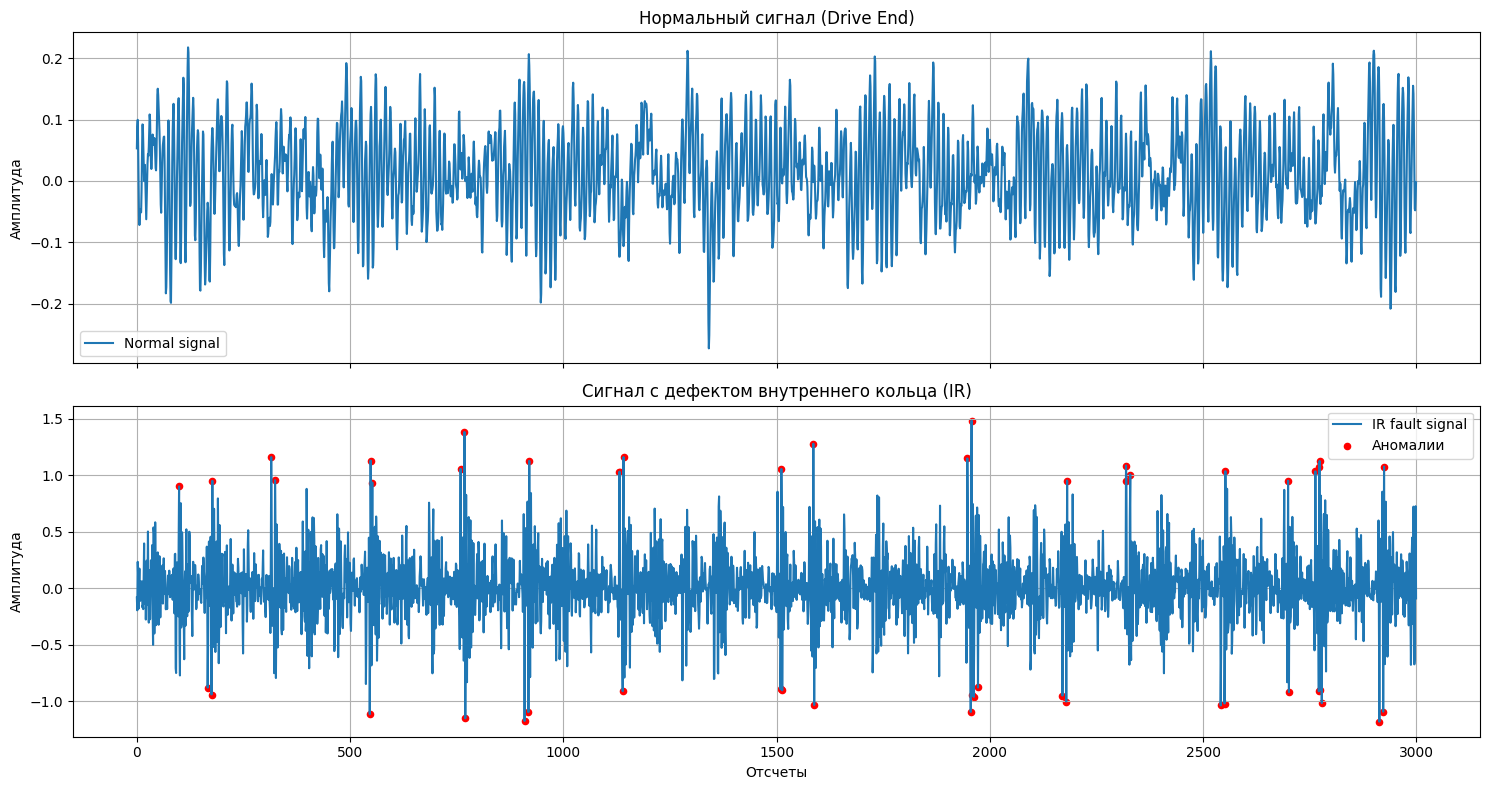

In [26]:
# Пути к папкам
IR_FOLDER = "Data/12k/DE/IR"
NORMAL_FOLDER = 'Data/Normal'

# --------------------------------------------------
# Функция поиска канала DE_time внутри .mat файла
# --------------------------------------------------
def get_de_signal(mat_data):
    for key in mat_data.keys():
        if 'DE_time' in key:
            return key, mat_data[key].flatten()
    return None, None

# --------------------------------------------------
# Загрузка одного файла
# --------------------------------------------------
def load_signal(filepath):
    mat_data = loadmat(filepath)
    signal_name, signal = get_de_signal(mat_data)

    if signal is None:
        raise ValueError(f'В файле {filepath} не найден канал DE_time')

    return signal_name, signal

# --------------------------------------------------
# Получение списка файлов
# --------------------------------------------------
ir_files = sorted([
    os.path.join(IR_FOLDER, f)
    for f in os.listdir(IR_FOLDER)
    if f.endswith('.mat')
])

normal_files = sorted([
    os.path.join(NORMAL_FOLDER, f)
    for f in os.listdir(NORMAL_FOLDER)
    if f.endswith('.mat')
])

# --------------------------------------------------
# Берем по одному примеру из каждого класса
# --------------------------------------------------
ir_file = ir_files[0]
normal_file = normal_files[0]

ir_name, ir_signal = load_signal(ir_file)
normal_name, normal_signal = load_signal(normal_file)

# --------------------------------------------------
# Ограничение длины для удобства визуализации
# --------------------------------------------------
N = 3000

ir_signal = ir_signal[:N]
normal_signal = normal_signal[:N]

# --------------------------------------------------
# Простое выделение аномалий
# Используем z-score
# --------------------------------------------------
ir_mean = np.mean(ir_signal)
ir_std = np.std(ir_signal)

z_scores = np.abs((ir_signal - ir_mean) / ir_std)

# Порог аномалии
threshold = 3
anomaly_idx = np.where(z_scores > threshold)[0]

# --------------------------------------------------
# Построение графиков
# --------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# ---------- Normal ----------
axes[0].plot(normal_signal, label='Normal signal')
axes[0].set_title('Нормальный сигнал (Drive End)')
axes[0].set_ylabel('Амплитуда')
axes[0].grid(True)
axes[0].legend()

# ---------- IR ----------
axes[1].plot(ir_signal, label='IR fault signal')

# Выделение аномалий
axes[1].scatter(
    anomaly_idx,
    ir_signal[anomaly_idx],
    color='red',
    s=20,
    label='Аномалии'
)

axes[1].set_title('Сигнал с дефектом внутреннего кольца (IR)')
axes[1].set_xlabel('Отсчеты')
axes[1].set_ylabel('Амплитуда')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.savefig("./IRVisual")
plt.show()

In [27]:
def load_channels(filepath):
    mat_data = loadmat(filepath) 
    channels = {} 
    for key in mat_data.keys():
        if '_time' in key: 
            channels[key] = mat_data[key].flatten() 
    return channels
def calculate_statistics(signal): 
    stats = {
        'count': len(signal),
        'mean': np.mean(signal), 
        'std': np.std(signal), 
        'min': np.min(signal), 
        'Q1': np.percentile(signal, 25), 
        'Q2 (median)': np.median(signal), 
        'Q3': np.percentile(signal, 75), 
        'max': np.max(signal) } 
    return stats

example_file = os.path.join(IR_FOLDER, os.listdir(IR_FOLDER)[0]) 

channels = load_channels(example_file) 

results = [] 

for channel_name, signal in channels.items(): 
    stats = calculate_statistics(signal) 
    stats['channel'] = channel_name 
    results.append(stats)

df_stats = pd.DataFrame(results) # Перенос столбца channel в начало 

cols = ['channel'] + [col for col in df_stats.columns if col != 'channel'] 

df_stats = df_stats[cols] 

print(df_stats)

sampling_frequency = 12000 

print(f'Частота дискретизации: {sampling_frequency} Гц')

        channel   count      mean       std       min        Q1  Q2 (median)  \
0  X105_DE_time  121265  0.013444  0.291216 -1.379886 -0.135146     0.007147   
1  X105_FE_time  121265  0.033019  0.243440 -1.139656 -0.123889     0.039036   
2  X105_BA_time  121265  0.006098  0.090378 -0.349100 -0.055125     0.005231   

         Q3       max  
0  0.160161  1.739030  
1  0.197647  0.963171  
2  0.065346  0.372035  
Частота дискретизации: 12000 Гц


In [28]:
# Анализ пропущенных значений и потенциальных выбросов по правилу трех сигм
quality_results = []

for channel_name, signal in channels.items():
    signal = np.asarray(signal, dtype=float)
    missing_mask = np.isnan(signal)
    valid_signal = signal[~missing_mask]

    missing_count = int(missing_mask.sum())
    missing_percent = missing_count / len(signal) * 100

    if len(valid_signal) == 0:
        mean_value = np.nan
        std_value = np.nan
        lower_bound = np.nan
        upper_bound = np.nan
        outliers_count = 0
        outliers_percent = 0
    else:
        mean_value = np.mean(valid_signal)
        std_value = np.std(valid_signal)
        lower_bound = mean_value - 3 * std_value
        upper_bound = mean_value + 3 * std_value
        outliers_mask = (valid_signal < lower_bound) | (valid_signal > upper_bound)
        outliers_count = int(outliers_mask.sum())
        outliers_percent = outliers_count / len(valid_signal) * 100

    quality_results.append({
        'channel': channel_name,
        'count': len(signal),
        'missing_count': missing_count,
        'missing_percent': missing_percent,
        'mean': mean_value,
        'std': std_value,
        'lower_3sigma': lower_bound,
        'upper_3sigma': upper_bound,
        'outliers_3sigma_count': outliers_count,
        'outliers_3sigma_percent': outliers_percent,
    })

df_quality = pd.DataFrame(quality_results)

print('Доля пропущенных значений и потенциальные выбросы по каналам:')
display(df_quality)


Доля пропущенных значений и потенциальные выбросы по каналам:


,channel,count,missing_count,missing_percent,mean,std,lower_3sigma,upper_3sigma,outliers_3sigma_count,outliers_3sigma_percent
0,X105_DE_time,121265,0,0.0,0.013444,0.291216,-0.860204,0.887091,1939,1.598977
1,X105_FE_time,121265,0,0.0,0.033019,0.243440,-0.697301,0.763339,610,0.503031
2,X105_BA_time,121265,0,0.0,0.006098,0.090378,-0.265037,0.277232,347,0.286150


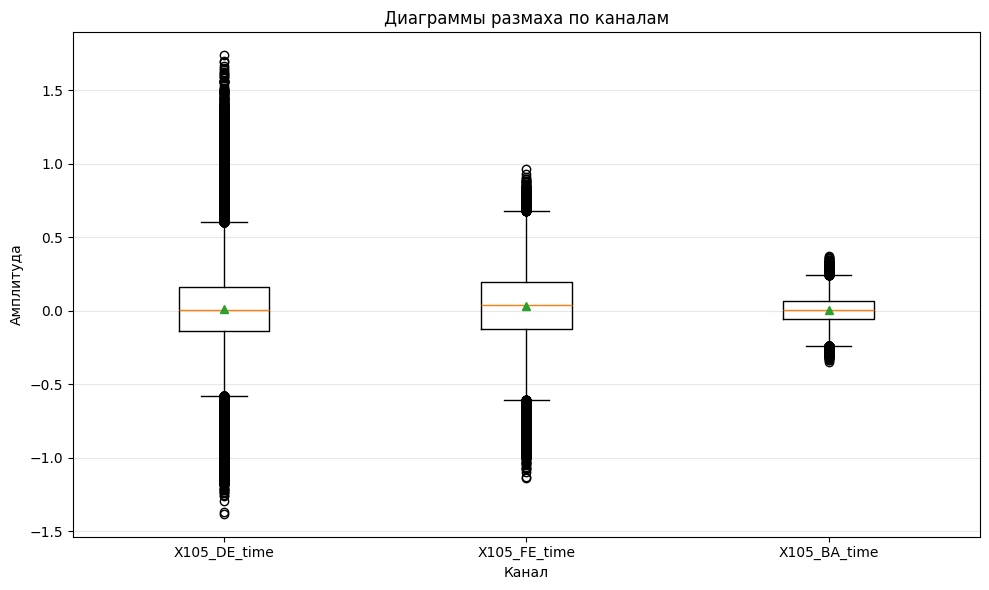

In [29]:
# Диаграмма размаха для визуального выявления выбросов в каждом канале
boxplot_data = [
    np.asarray(signal, dtype=float)[~np.isnan(np.asarray(signal, dtype=float))]
    for signal in channels.values()
]

plt.figure(figsize=(10, 6))
plt.boxplot(boxplot_data, tick_labels=list(channels.keys()), showmeans=True)
plt.title('Диаграммы размаха по каналам')
plt.xlabel('Канал')
plt.ylabel('Амплитуда')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('./channels_boxplot.png', dpi=150)
plt.show()


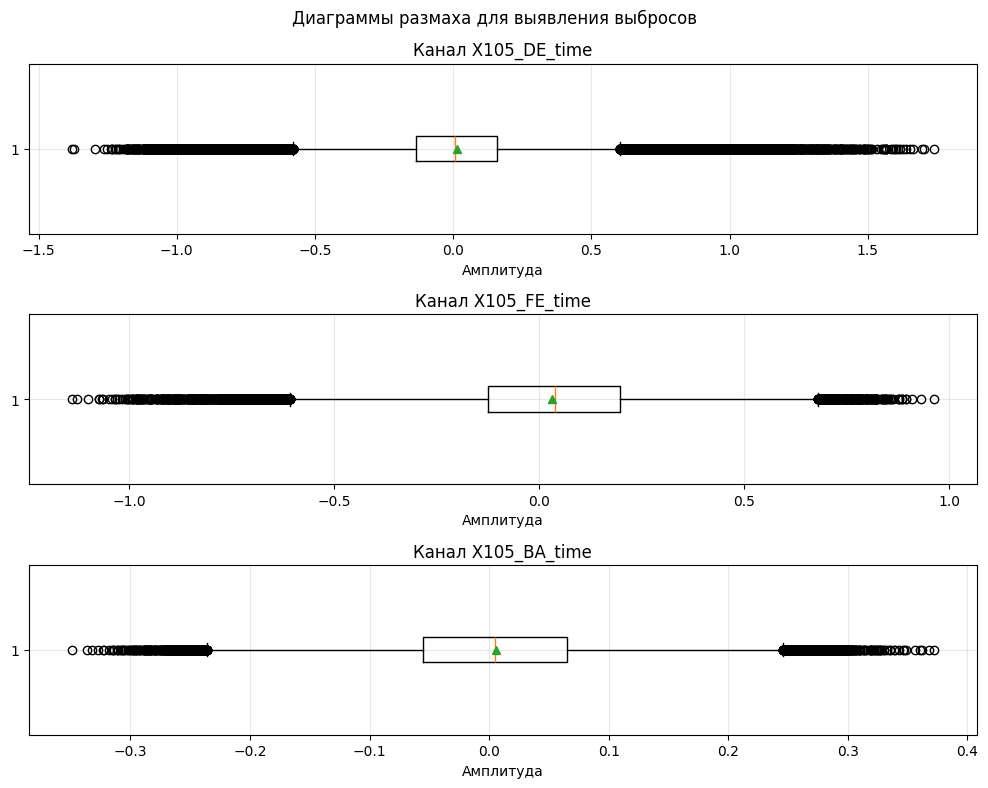

In [30]:
#4
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

for ax, (name, signal) in zip(axes, channels.items()):
    clean_signal = np.asarray(signal, dtype=float)
    clean_signal = clean_signal[~np.isnan(clean_signal)]

    ax.boxplot(clean_signal, vert=False, showmeans=True)

    ax.set_title(f'Канал {name}')
    ax.set_xlabel('Амплитуда')
    ax.grid(alpha=0.3)

plt.suptitle('Диаграммы размаха для выявления выбросов')
plt.tight_layout()
plt.savefig('./outliers_boxplots.png', dpi=150)
plt.show()

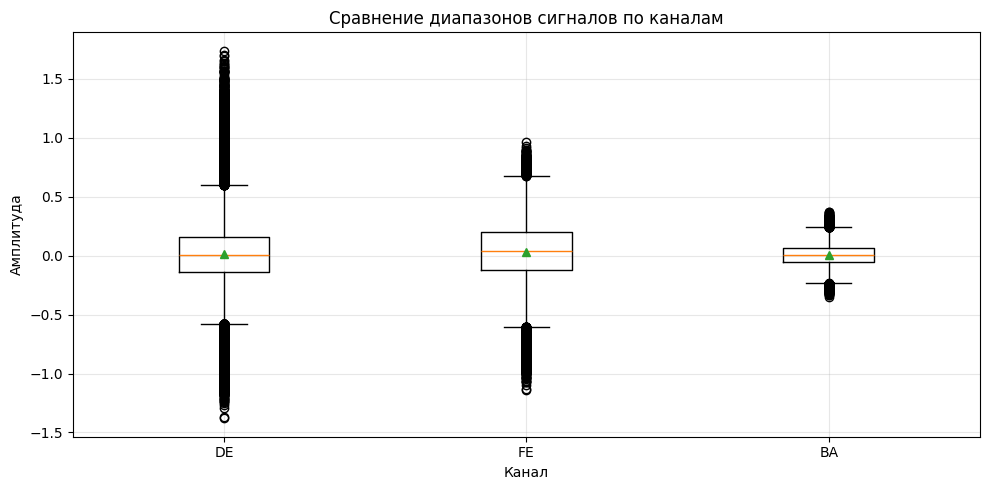

In [31]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# --------------------------------------------------
# Функция извлечения всех нужных каналов
# --------------------------------------------------
def get_channels(mat_data):
    channels = {}

    for key in mat_data.keys():
        if 'DE_time' in key:
            channels['DE'] = mat_data[key].flatten()
        elif 'FE_time' in key:
            channels['FE'] = mat_data[key].flatten()
        elif 'BA_time' in key:
            channels['BA'] = mat_data[key].flatten()

    return channels

# --------------------------------------------------
# Загрузка одного файла (например IR или Normal)
# --------------------------------------------------
def load_channels(filepath):
    mat_data = loadmat(filepath)
    return get_channels(mat_data)

# --------------------------------------------------
# Берём один файл (можешь поменять на IR / Normal)
# --------------------------------------------------
file_path = ir_files[0]   # или normal_files[0]

channels = load_channels(file_path)

# --------------------------------------------------
# Подготовка данных для графика
# --------------------------------------------------
data_to_plot = [channels[k] for k in ['DE', 'FE', 'BA']]
labels = ['DE', 'FE', 'BA']

# --------------------------------------------------
# Построение boxplot
# --------------------------------------------------
plt.figure(figsize=(10, 5))

plt.boxplot(data_to_plot, tick_labels=labels, showmeans=True)

plt.title('Сравнение диапазонов сигналов по каналам')
plt.xlabel('Канал')
plt.ylabel('Амплитуда')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./channels_boxplot.png', dpi=150)
plt.show()

          DE        FE        BA
DE  1.000000 -0.008507 -0.057355
FE -0.008507  1.000000 -0.432353
BA -0.057355 -0.432353  1.000000


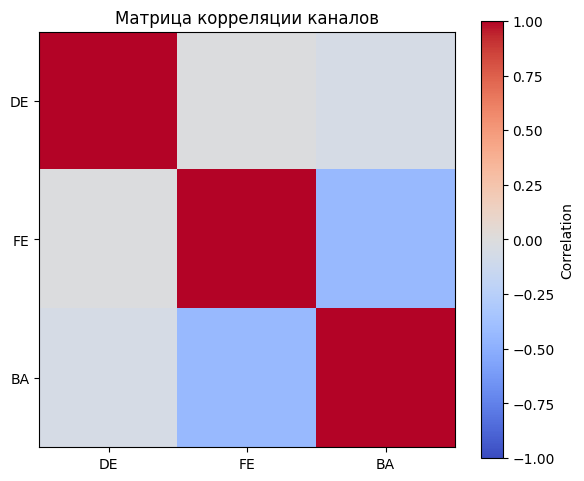

In [32]:
#6
# Берём один файл (IR или Normal — не принципиально для корреляции структуры)
file_path = ir_files[0]
channels = load_channels(file_path)

# Формируем DataFrame
df = pd.DataFrame({
    'DE': channels['DE'],
    'FE': channels['FE'],
    'BA': channels['BA']
})

# Корреляционная матрица
corr_matrix = df.corr(method='pearson')

print(corr_matrix)

# Визуализация
plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')

plt.xticks(range(len(df.columns)), df.columns)
plt.yticks(range(len(df.columns)), df.columns)

plt.title('Матрица корреляции каналов')
plt.tight_layout()
plt.savefig("./matrixCorr.png")
plt.show()

[        nan         nan         nan ... -0.05743197  0.05468477
  0.11963473]


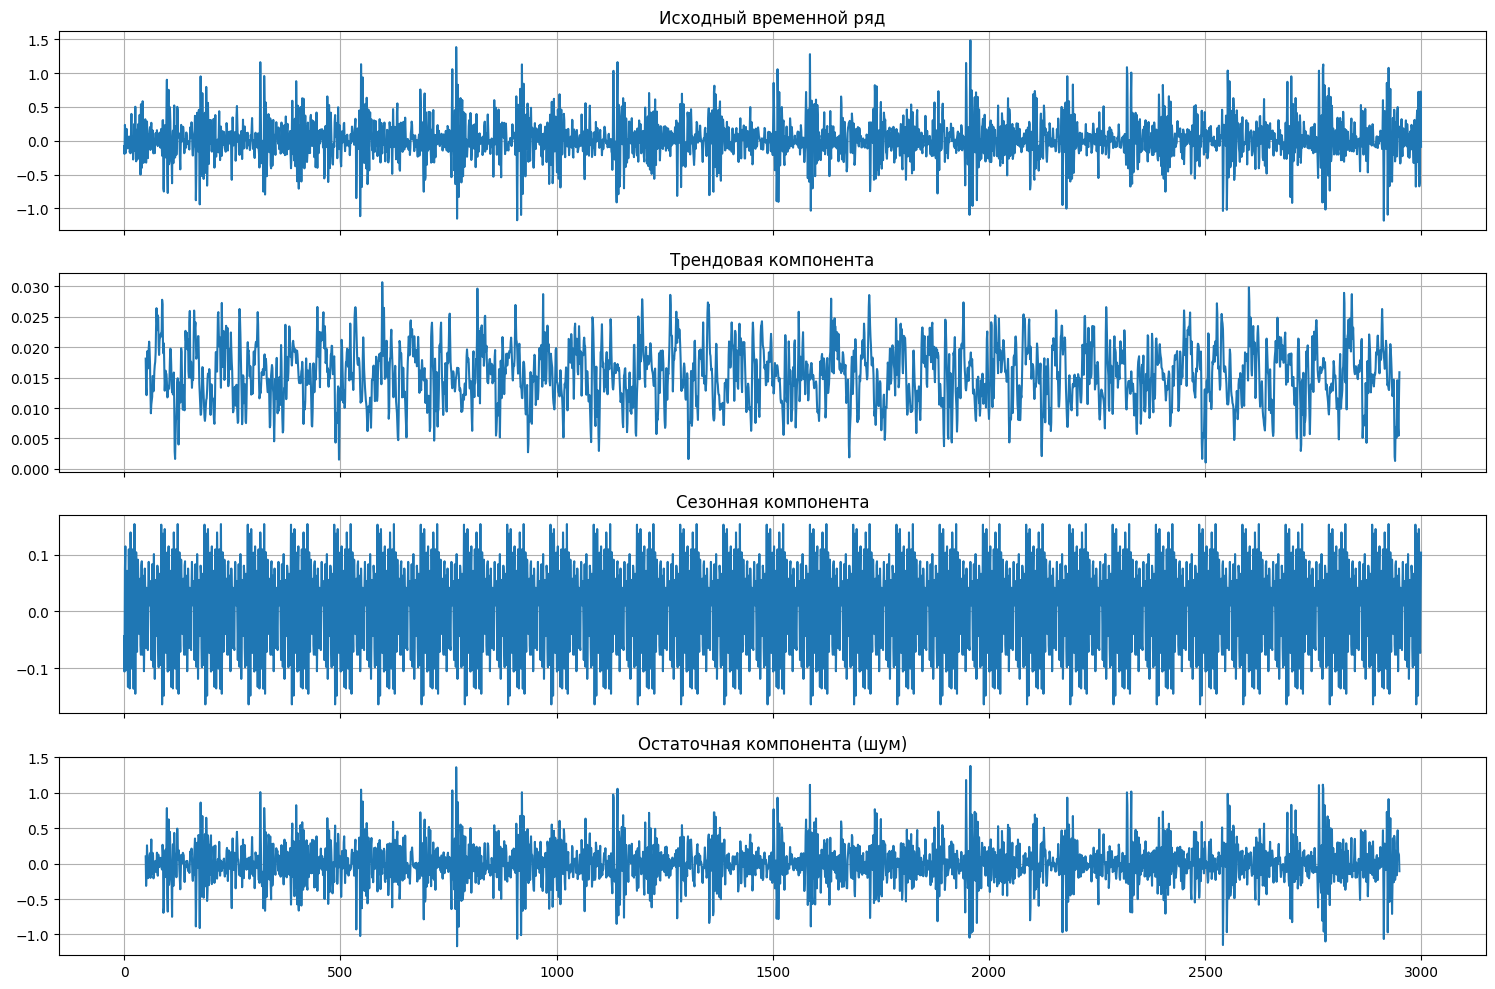

In [34]:
#7
# выбираем один канал (например DE)

signal = ir_signal[:5000]

# декомпозиция
period = 100
result = seasonal_decompose(signal, model='additive', period=period)

trend = pd.Series(result.trend).interpolate().values
seasonal = result.seasonal

signal_clean = trend + seasonal

print(signal_clean)
# --------------------------------------------------
# построение 4 графиков
# --------------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

# исходный ряд
axes[0].plot(signal)
axes[0].set_title('Исходный временной ряд')
axes[0].grid(True)

# тренд
axes[1].plot(result.trend)
axes[1].set_title('Трендовая компонента')
axes[1].grid(True)

# сезонная компонента
axes[2].plot(result.seasonal)
axes[2].set_title('Сезонная компонента')
axes[2].grid(True)

# остатки (шум)
axes[3].plot(result.resid)
axes[3].set_title('Остаточная компонента (шум)')
axes[3].grid(True)

plt.tight_layout()
plt.savefig("./Decompose.png")
plt.show()



In [36]:
#7
# безопасное восстановление компонент
trend = np.nan_to_num(result.trend)
seasonal = np.nan_to_num(result.seasonal)
residual = np.nan_to_num(result.resid)

# полезный сигнал
signal_clean = trend + seasonal

# дисперсии
signal_var = np.var(signal_clean)
noise_var = np.var(residual)

# SNR
snr = 10 * np.log10(signal_var / noise_var)

print(f"SNR: {snr:.2f} dB")

SNR: -10.99 dB


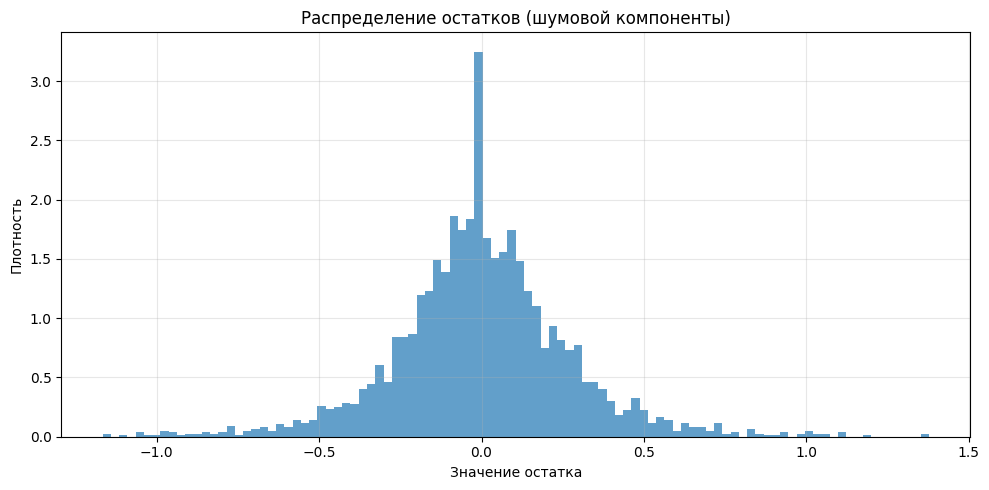

In [39]:
#7
# остаточная компонента (шум)
residual = np.nan_to_num(result.resid)

plt.figure(figsize=(10, 5))

plt.hist(residual, bins=100, density=True, alpha=0.7)

plt.title('Распределение остатков (шумовой компоненты)')
plt.xlabel('Значение остатка')
plt.ylabel('Плотность')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("./RapredOstatok.png")
plt.show()